# Task 3 Walkthrough: Passive Radar & SoO Positioning (Stages 1-4)

This notebook is the assignment walkthrough deliverable scaffold.

It covers:
1. Stage 1: Synthetic signal generation.
2. Stage 2: CAF delay-Doppler estimation.
3. Stage 3: Bi-static and multi-static geometry with least-squares intersection.
4. Stage 4: GDOP analysis and geometry-driven error behavior.

It also includes a synthetic benchmark table across SNR levels (`10`, `0`, `-10` dB).

## 0) Environment Setup

Run from repo root after activating your environment.

```powershell
conda activate C:\\Users\\general\\radioconda
$env:PYTHONPATH = "src"
```

In [1]:
import os, sys
from pathlib import Path

# Force repo root as working dir
os.chdir(r"C:\swarm\repos\SoO_Foundations")

# Add src to import path
src = Path.cwd() / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))

print("cwd:", Path.cwd())
print("src path added:", src)



from pathlib import Path
import sys
import subprocess
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# Make package imports work when notebook runs from repo root.
repo_root = Path.cwd()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

data_dir = repo_root / "data"
results_dir = repo_root / "results"
data_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
print("Setup complete.")

cwd: C:\swarm\repos\SoO_Foundations
src path added: C:\swarm\repos\SoO_Foundations\src
Setup complete.


## 1) Stage 1: Synthetic SoO Signal Generator

Generate synthetic direct-path and reflected-path IQ pairs for controlled validation.

In [2]:
from soo_foundations.soo_sim import generate_gaussian_pair, generate_chirp_pair, write_c64

samp_rate = 1e6
duration = 0.2
n_samples = int(round(duration * samp_rate))

# Gaussian pair.
g_orig, g_ref = generate_gaussian_pair(
    samp_rate=samp_rate,
    n_samples=n_samples,
    delay_samps=1200,
    doppler_hz=50e3,
    attn=0.9,
    snr_db=10.0,
    seed=42,
)
write_c64(data_dir / "original_gaussian.c64", g_orig)
write_c64(data_dir / "reflected_gaussian.c64", g_ref)

# Chirp pair.
c_orig, c_ref = generate_chirp_pair(
    samp_rate=samp_rate,
    duration=duration,
    f_start=-100e3,
    f_end=100e3,
    amp=1.0,
    delay_samps=1200,
    doppler_hz=50e3,
    attn=0.9,
    snr_db=10.0,
)
write_c64(data_dir / "original_chirp.c64", c_orig)
write_c64(data_dir / "reflected_chirp.c64", c_ref)

print("Stage 1 data written:")
print(" -", data_dir / "original_gaussian.c64")
print(" -", data_dir / "reflected_gaussian.c64")
print(" -", data_dir / "original_chirp.c64")
print(" -", data_dir / "reflected_chirp.c64")

Stage 1 data written:
 - C:\swarm\repos\SoO_Foundations\data\original_gaussian.c64
 - C:\swarm\repos\SoO_Foundations\data\reflected_gaussian.c64
 - C:\swarm\repos\SoO_Foundations\data\original_chirp.c64
 - C:\swarm\repos\SoO_Foundations\data\reflected_chirp.c64


## 2) Stage 2: CAF (Matched Filtering) and Heatmap

Compute CAF and verify that estimated delay/Doppler peak matches the injected values.

Estimated delay:   200 samples
Estimated doppler: 49000.00 Hz
|CAF| peak:         4.001e+04


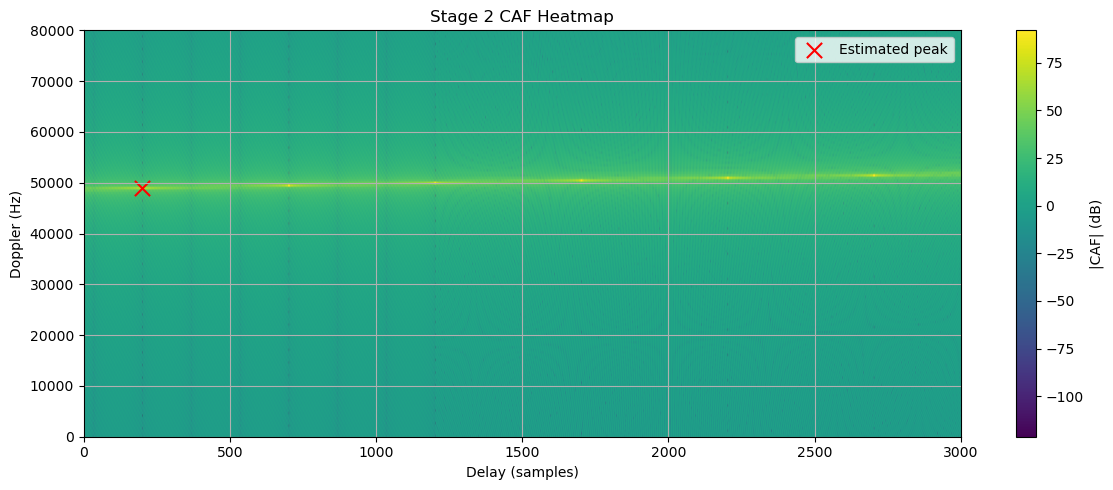

In [3]:
from soo_foundations.soo_caf import caf_fftbank, caf_peak

s_ref = np.fromfile(data_dir / "original_chirp.c64", dtype=np.complex64)
s_surv = np.fromfile(data_dir / "reflected_chirp.c64", dtype=np.complex64)

delays = np.arange(0, 3001, 1, dtype=int)
dopplers = np.linspace(0, 80000, 161, dtype=float)

caf = caf_fftbank(
    s_ref=s_ref,
    s_surv=s_surv,
    samp_rate=samp_rate,
    delays=delays,
    dopplers=dopplers,
)
pk_delay, pk_fd, _, pk_mag = caf_peak(caf, delays, dopplers)

print(f"Estimated delay:   {pk_delay} samples")
print(f"Estimated doppler: {pk_fd:.2f} Hz")
print(f"|CAF| peak:         {pk_mag:.4g}")

mag_db = 20.0 * np.log10(np.maximum(np.abs(caf), 1e-12))
plt.figure(figsize=(12, 5))
plt.imshow(
    mag_db,
    extent=[delays[0], delays[-1], dopplers[0], dopplers[-1]],
    origin="lower",
    aspect="auto",
    cmap="viridis",
)
plt.colorbar(label="|CAF| (dB)")
plt.scatter([pk_delay], [pk_fd], c="r", marker="x", s=120, label="Estimated peak")
plt.title("Stage 2 CAF Heatmap")
plt.xlabel("Delay (samples)")
plt.ylabel("Doppler (Hz)")
plt.legend()
plt.tight_layout()
plt.savefig(results_dir / "notebook_stage2_caf_heatmap.png", dpi=150)
plt.show()

## 3) Stage 3: Multi-static Intersection (3 Towers) with Least Squares

Simulate one receiver and three transmitters, generate noisy bistatic ranges, and estimate `(x, y)` by weighted least squares.

Converged: True (converged_step)
True target: [7000. 5200.]
Estimated:   [6998.0815767  5201.40910824]
Position error: 2.380 m


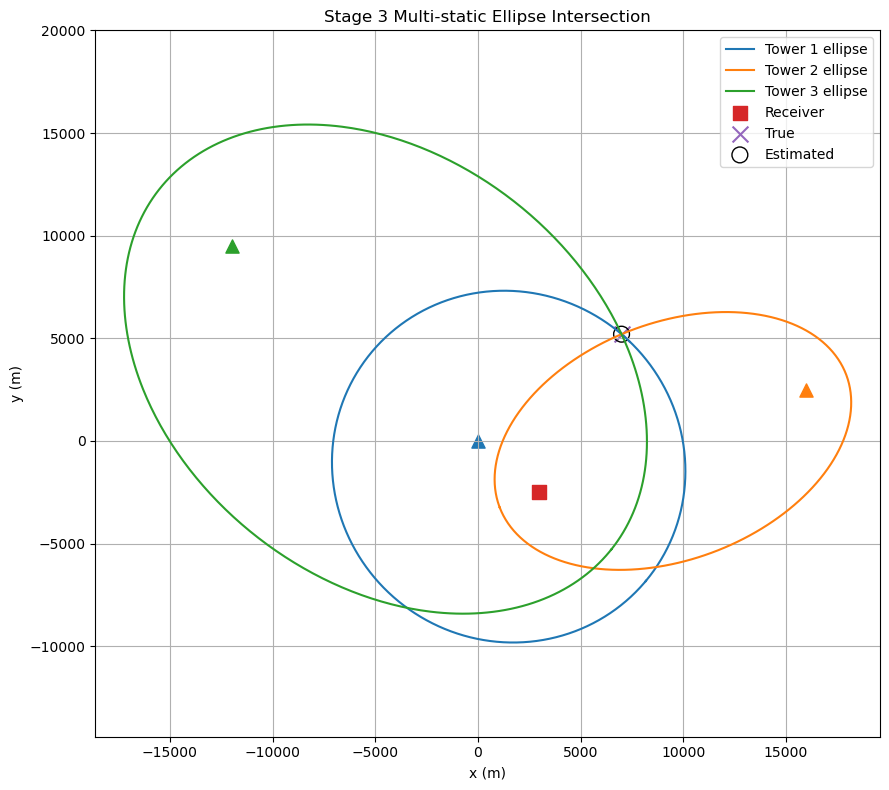

In [4]:
from soo_foundations.s3_solver import (
    predict_bistatic_range_2d,
    make_bistatic_measurements_2d,
    solve_position_bistatic_wls_2d,
)

def ellipse_points(tx_xy, rx_xy, range_sum_m, n=500):
    tx = np.asarray(tx_xy, dtype=float)
    rx = np.asarray(rx_xy, dtype=float)
    focal_dist = float(np.linalg.norm(rx - tx))
    if range_sum_m < focal_dist:
        return np.zeros((0, 2), dtype=float)
    a = 0.5 * float(range_sum_m)
    c = 0.5 * focal_dist
    b = np.sqrt(max(a * a - c * c, 0.0))
    t = np.linspace(0, 2*np.pi, n)
    p_local = np.column_stack([a * np.cos(t), b * np.sin(t)])
    center = 0.5 * (tx + rx)
    d = rx - tx
    th = np.arctan2(d[1], d[0])
    ct, st = np.cos(th), np.sin(th)
    rot = np.array([[ct, -st], [st, ct]], dtype=float)
    return p_local @ rot.T + center

rng = np.random.default_rng(7)
txs = np.array([[0.0, 0.0], [16000.0, 2500.0], [-12000.0, 9500.0]], dtype=float)
rx = np.array([3000.0, -2500.0], dtype=float)
target_true = np.array([7000.0, 5200.0], dtype=float)
noise_sigma_m = 8.0

measured_ranges = []
for tx in txs:
    r_true = predict_bistatic_range_2d(target_true, tx, rx)
    measured_ranges.append(float(r_true + rng.normal(0.0, noise_sigma_m)))

meas = make_bistatic_measurements_2d(
    measured_ranges_m=measured_ranges,
    tx_positions_xy=txs,
    rx_positions_xy=[rx for _ in range(len(txs))],
    sigma_ranges_m=[noise_sigma_m] * len(txs),
)
out = solve_position_bistatic_wls_2d(measurements=meas)
est = np.array(out.estimated_xy, dtype=float)
err = float(np.linalg.norm(est - target_true))

print(f"Converged: {out.success} ({out.reason})")
print(f"True target: {target_true}")
print(f"Estimated:   {est}")
print(f"Position error: {err:.3f} m")

plt.figure(figsize=(9, 8))
for i, (tx, r_m) in enumerate(zip(txs, measured_ranges), start=1):
    pts = ellipse_points(tx, rx, r_m)
    if pts.shape[0] > 0:
        plt.plot(pts[:, 0], pts[:, 1], label=f"Tower {i} ellipse")
    plt.scatter([tx[0]], [tx[1]], marker="^", s=90)
plt.scatter([rx[0]], [rx[1]], marker="s", s=100, label="Receiver")
plt.scatter([target_true[0]], [target_true[1]], marker="x", s=130, label="True")
plt.scatter([est[0]], [est[1]], facecolors="none", edgecolors="k", s=130, label="Estimated")
plt.title("Stage 3 Multi-static Ellipse Intersection")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.savefig(results_dir / "notebook_stage3_multistatic.png", dpi=150)
plt.show()

### 3.1) Requested Plot: Iso-range Ellipses (Single Tx/Rx Pair)

This plot explicitly satisfies the assignment request for isorange ellipses from one transmitter/receiver pair.


In [ ]:
def single_pair_isorange_ellipse_points(tx_xy, rx_xy, range_sum_m, n=500):
    tx = np.asarray(tx_xy, dtype=float)
    rx = np.asarray(rx_xy, dtype=float)
    focal_dist = float(np.linalg.norm(rx - tx))
    if range_sum_m < focal_dist:
        return np.zeros((0, 2), dtype=float)
    a = 0.5 * float(range_sum_m)
    c = 0.5 * focal_dist
    b = np.sqrt(max(a * a - c * c, 0.0))
    t = np.linspace(0.0, 2.0 * np.pi, n)
    p_local = np.column_stack([a * np.cos(t), b * np.sin(t)])
    center = 0.5 * (tx + rx)
    d = rx - tx
    th = np.arctan2(d[1], d[0])
    ct, st = np.cos(th), np.sin(th)
    rot = np.array([[ct, -st], [st, ct]], dtype=float)
    return p_local @ rot.T + center

tx_pair = np.array([0.0, 0.0], dtype=float)
rx_pair = np.array([1000.0, 0.0], dtype=float)
ranges_pair = [1200.0, 1400.0, 1700.0]

plt.figure(figsize=(8, 7))
for r in ranges_pair:
    pts = single_pair_isorange_ellipse_points(tx_pair, rx_pair, r, n=700)
    if pts.shape[0] > 0:
        plt.plot(pts[:, 0], pts[:, 1], linewidth=2.0, label=f"R={r:.0f} m")

plt.scatter([tx_pair[0]], [tx_pair[1]], marker="^", s=120, label="Tx")
plt.scatter([rx_pair[0]], [rx_pair[1]], marker="s", s=120, label="Rx")
plt.title("Requested Stage 3 Plot: Single-Pair Iso-range Ellipses")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.savefig(results_dir / "notebook_stage3_isorange_single_pair.png", dpi=150)
plt.show()


## 4) Stage 4: GDOP and Baseline Blur Experiment

Use the Stage 4 script to sweep target distance-to-baseline and show near-baseline degradation.

Running: C:\Users\general\radioconda\python.exe -B src/s4_gdop_analysis.py --runs_per_case 200 --noise_sigma_m 8 --baseline_tx_index 1 --baseline_distances_m 6000,4000,2500,1500,800,400,200 --out_csv C:\swarm\repos\SoO_Foundations\results\s4_gdop_analysis.csv --save_png C:\swarm\repos\SoO_Foundations\results\s4_gdop_analysis.png --no_show


,distance_to_baseline_m,gdop,cond_hth,convergence_rate_pct,rmse_m,median_err_m,p95_err_m,blur_area_m2,target_x_m,target_y_m
0,6000.0,0.879946,3.210791,100.0,6.888862,5.258196,12.562381,62.591374,5191.106398,3484.327678
1,4000.0,0.897512,2.672232,100.0,6.999875,5.789366,12.152748,72.488081,3910.737599,1947.885118
2,2500.0,0.912200,1.795036,100.0,7.332436,5.912604,12.928931,79.905271,2950.460999,795.553199
3,1500.0,0.993127,1.391942,100.0,7.912434,6.891531,13.923524,95.469138,2310.276599,27.331919
4,800.0,1.357265,3.958539,100.0,10.898655,8.682326,20.251357,156.852727,1862.147520,-510.422976
5,400.0,2.389752,15.722246,100.0,18.960733,14.000321,36.499570,268.781215,1606.073760,-817.711488
6,200.0,4.570312,62.765728,100.0,39.263790,26.350832,74.333957,581.413074,1478.036880,-971.355744


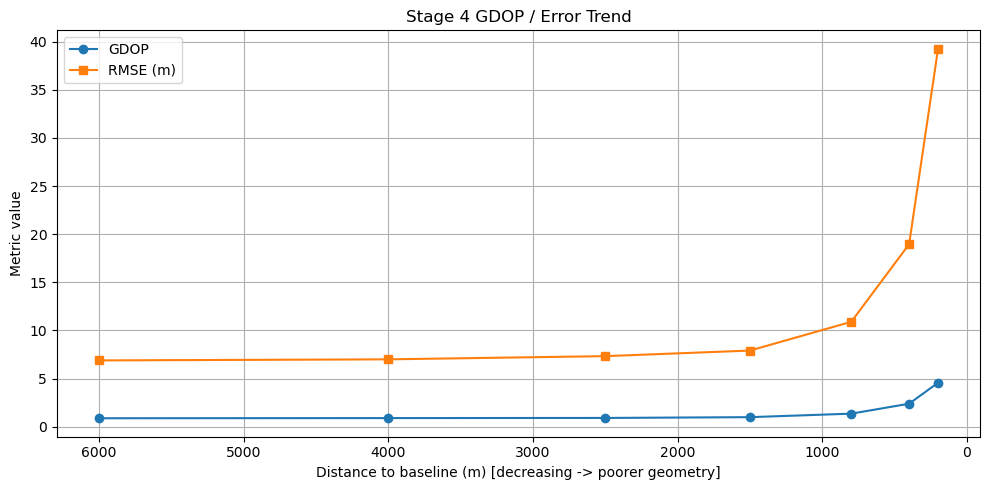

In [5]:
cmd = [
    sys.executable,
    "-B",
    "src/s4_gdop_analysis.py",
    "--runs_per_case", "200",
    "--noise_sigma_m", "8",
    "--baseline_tx_index", "1",
    "--baseline_distances_m", "6000,4000,2500,1500,800,400,200",
    "--out_csv", str(results_dir / "s4_gdop_analysis.csv"),
    "--save_png", str(results_dir / "s4_gdop_analysis.png"),
    "--no_show",
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

gdop_df = pd.read_csv(results_dir / "s4_gdop_analysis.csv")
display(gdop_df)

plt.figure(figsize=(10, 5))
plt.plot(gdop_df["distance_to_baseline_m"], gdop_df["gdop"], "o-", label="GDOP")
plt.plot(gdop_df["distance_to_baseline_m"], gdop_df["rmse_m"], "s-", label="RMSE (m)")
plt.gca().invert_xaxis()
plt.xlabel("Distance to baseline (m) [decreasing -> poorer geometry]")
plt.ylabel("Metric value")
plt.title("Stage 4 GDOP / Error Trend")
plt.legend()
plt.tight_layout()
plt.show()

### 4.1) Requested Plot: Near-Baseline Blur Visualization

The Stage 4 script already creates a 4-panel figure containing far vs near baseline estimate clouds.
This cell embeds that exact requested visualization directly in the notebook.


In [ ]:
gdop_img_path = results_dir / "s4_gdop_analysis.png"
img = plt.imread(gdop_img_path)
plt.figure(figsize=(14, 9))
plt.imshow(img)
plt.axis("off")
plt.title("Requested Stage 4 Plot: GDOP Near-Baseline Blur")
plt.tight_layout()
plt.show()


## 5) Synthetic Benchmark Table Across SNR (10, 0, -10 dB)

This section produces a coordinate-recovery benchmark table using Stage 3 multi-static least-squares solving.

Method:
- Keep geometry fixed.
- Map SNR to measurement noise (higher SNR -> lower range noise).
- Run Monte Carlo and report RMSE/median/p95/convergence.

Note: this is a synthetic benchmark for assignment reporting and intuition.

In [6]:
snr_levels_db = [10.0, 0.0, -10.0]
runs_per_case = 400
base_sigma_m = 12.0  # noise at 0 dB reference

rng = np.random.default_rng(23)
rows = []

for snr_db in snr_levels_db:
    # Simple synthetic mapping from SNR to range noise sigma.
    sigma_m = base_sigma_m / (10.0 ** (snr_db / 20.0))

    errs = []
    success = 0
    for _ in range(runs_per_case):
        measured = []
        for tx in txs:
            r_true = predict_bistatic_range_2d(target_true, tx, rx)
            measured.append(float(r_true + rng.normal(0.0, sigma_m)))

        meas = make_bistatic_measurements_2d(
            measured_ranges_m=measured,
            tx_positions_xy=txs,
            rx_positions_xy=[rx for _ in range(len(txs))],
            sigma_ranges_m=[sigma_m] * len(txs),
        )
        out = solve_position_bistatic_wls_2d(measurements=meas)
        est = np.array(out.estimated_xy, dtype=float)
        if out.success and np.all(np.isfinite(est)):
            success += 1
            errs.append(float(np.linalg.norm(est - target_true)))

    e = np.asarray(errs, dtype=float)
    rows.append(
        {
            "snr_db": snr_db,
            "sigma_range_m": sigma_m,
            "runs": runs_per_case,
            "convergence_rate_pct": 100.0 * success / runs_per_case,
            "rmse_m": float(np.sqrt(np.mean(e * e))) if e.size else np.nan,
            "median_err_m": float(np.median(e)) if e.size else np.nan,
            "p95_err_m": float(np.percentile(e, 95.0)) if e.size else np.nan,
        }
    )

bench_df = pd.DataFrame(rows).sort_values("snr_db", ascending=False)
display(bench_df)

bench_path = results_dir / "synthetic_benchmark_snr.csv"
bench_df.to_csv(bench_path, index=False)
print("Saved benchmark table:", bench_path)

,snr_db,sigma_range_m,runs,convergence_rate_pct,rmse_m,median_err_m,p95_err_m
0,10.0,3.794733,400,100.0,3.267998,2.625495,5.612993
1,0.0,12.000000,400,100.0,10.568278,8.164924,19.731952
2,-10.0,37.947332,400,100.0,32.829643,26.786752,57.859382


Saved benchmark table: C:\swarm\repos\SoO_Foundations\results\synthetic_benchmark_snr.csv


## 6) Summary Notes for Submission

In your final submission narrative, include:
- CAF derivation intuition (matched filtering in delay-Doppler domain).
- Geometry intuition (ellipse intersection conditioning).
- GDOP interpretation (near-baseline blur and error amplification).
- SNR benchmark observations from the generated table.